In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
area = pd.read_csv('/content/drive/MyDrive/arctic_data/area_long.csv')
europe =  pd.read_csv('/content/drive/MyDrive/arctic_data/europe_climate.csv')
sst =  pd.read_csv('/content/drive/MyDrive/arctic_data/Arctic_SST_Analysis_Data.csv')
ao =  pd.read_csv('/content/drive/MyDrive/arctic_data/ao_filtered.csv')

In [3]:
area.head()

,year,month,area_value,month_num,Era
0,2000,area_jan,14.25950,1,2000-2008 (pre)
1,2000,area_feb,15.14771,2,2000-2008 (pre)
2,2000,area_mar,15.25001,3,2000-2008 (pre)
3,2000,area_apr,14.57881,4,2000-2008 (pre)
4,2000,area_may,13.21552,5,2000-2008 (pre)


In [4]:
europe.head()

,year,mean_t850_celsius,date,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250
0,2000,-2.567078,2000-01-01,1.182831,5474.2715,0.000021,1015.94690,25.557714
1,2000,-2.935486,2000-01-02,1.415955,5458.6577,0.000025,1015.32117,24.525616
2,2000,-3.447266,2000-01-03,1.030762,5425.9585,0.000025,1012.57560,24.540684
3,2000,-3.548401,2000-01-04,1.439240,5389.6665,0.000028,1008.87980,22.146442
4,2000,-2.980896,2000-01-05,1.854767,5380.4897,0.000030,1006.60724,20.639778


In [5]:
sst.head()

,time,FRSEAICE,TSKINWTR,T10M,HFLUXWTR,EFLUXWTR,U10M,V10M
0,2000-01-01 00:30:00,0.502423,272.26678,250.90067,252.035550,89.892700,0.544332,0.148345
1,2000-02-01 00:30:00,0.515255,272.16122,252.79323,221.314960,82.977910,-0.326276,-0.253599
2,2000-03-01 00:30:00,0.517211,272.13068,254.50046,207.400000,80.391100,-0.634890,-0.397541
3,2000-04-01 00:30:00,0.518936,272.15040,260.33220,138.464160,63.603653,-0.286786,-0.351983
4,2000-05-01 00:30:00,0.500371,272.43660,267.82300,48.548542,32.018740,0.204275,-0.077439


In [6]:
ao.head()

,Date,YEAR,MONTH,AO_Index
0,2000-01-01,2000,1,0.665
1,2000-02-01,2000,2,1.060
2,2000-03-01,2000,3,-0.256
3,2000-04-01,2000,4,-0.576
4,2000-05-01,2000,5,1.152


###1. SST와 AREA

In [7]:
sst['time'] = pd.to_datetime(sst['time'])
area['date'] = pd.to_datetime(area['year'].astype(str) + '-' + area['month_num'].astype(str) + '-01')

# Displaying the first few rows to verify the changes
display(sst.head())
display(area.head())

,time,FRSEAICE,TSKINWTR,T10M,HFLUXWTR,EFLUXWTR,U10M,V10M
0,2000-01-01 00:30:00,0.502423,272.26678,250.90067,252.035550,89.892700,0.544332,0.148345
1,2000-02-01 00:30:00,0.515255,272.16122,252.79323,221.314960,82.977910,-0.326276,-0.253599
2,2000-03-01 00:30:00,0.517211,272.13068,254.50046,207.400000,80.391100,-0.634890,-0.397541
3,2000-04-01 00:30:00,0.518936,272.15040,260.33220,138.464160,63.603653,-0.286786,-0.351983
4,2000-05-01 00:30:00,0.500371,272.43660,267.82300,48.548542,32.018740,0.204275,-0.077439


,year,month,area_value,month_num,Era,date
0,2000,area_jan,14.25950,1,2000-2008 (pre),2000-01-01
1,2000,area_feb,15.14771,2,2000-2008 (pre),2000-02-01
2,2000,area_mar,15.25001,3,2000-2008 (pre),2000-03-01
3,2000,area_apr,14.57881,4,2000-2008 (pre),2000-04-01
4,2000,area_may,13.21552,5,2000-2008 (pre),2000-05-01


In [8]:
# Merge the two dataframes on their respective date columns
# For sst, we need to extract year and month to merge with 'area' data which is monthly
sst['year_month'] = sst['time'].dt.to_period('M')
area['year_month'] = area['date'].dt.to_period('M')

# Merge on the common year_month column
merged_df = pd.merge(sst, area, on='year_month', how='inner')

# Display the head of the merged dataframe to verify
display(merged_df.head())

,time,FRSEAICE,TSKINWTR,T10M,HFLUXWTR,EFLUXWTR,U10M,V10M,year_month,year,month,area_value,month_num,Era,date
0,2000-01-01 00:30:00,0.502423,272.26678,250.90067,252.035550,89.892700,0.544332,0.148345,2000-01,2000,area_jan,14.25950,1,2000-2008 (pre),2000-01-01
1,2000-02-01 00:30:00,0.515255,272.16122,252.79323,221.314960,82.977910,-0.326276,-0.253599,2000-02,2000,area_feb,15.14771,2,2000-2008 (pre),2000-02-01
2,2000-03-01 00:30:00,0.517211,272.13068,254.50046,207.400000,80.391100,-0.634890,-0.397541,2000-03,2000,area_mar,15.25001,3,2000-2008 (pre),2000-03-01
3,2000-04-01 00:30:00,0.518936,272.15040,260.33220,138.464160,63.603653,-0.286786,-0.351983,2000-04,2000,area_apr,14.57881,4,2000-2008 (pre),2000-04-01
4,2000-05-01 00:30:00,0.500371,272.43660,267.82300,48.548542,32.018740,0.204275,-0.077439,2000-05,2000,area_may,13.21552,5,2000-2008 (pre),2000-05-01


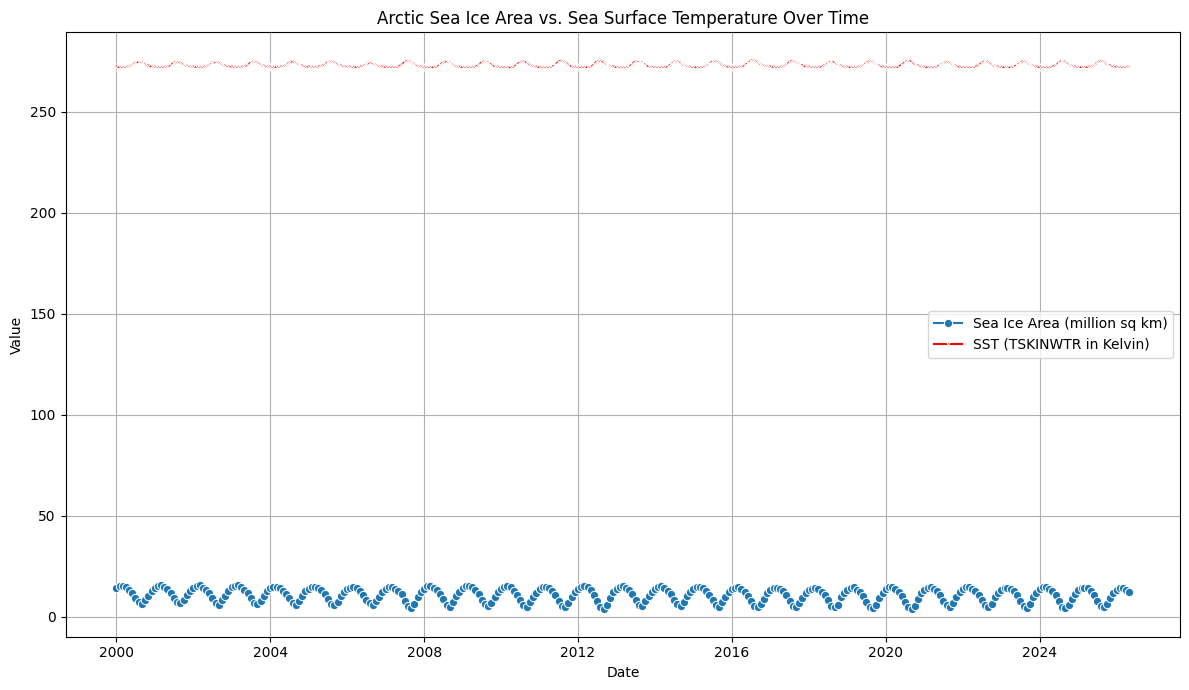

In [9]:
# Plotting the relationship between SST (TSKINWTR) and Sea Ice Area
plt.figure(figsize=(12, 7))
sns.lineplot(x='date', y='area_value', data=merged_df, label='Sea Ice Area (million sq km)', marker='o', errorbar=None)
sns.lineplot(x='date', y='TSKINWTR', data=merged_df, label='SST (TSKINWTR in Kelvin)', marker='x', errorbar=None, color='red')

plt.title('Arctic Sea Ice Area vs. Sea Surface Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Correlation between Sea Ice Area and Sea Surface Temperature (TSKINWTR): -0.89


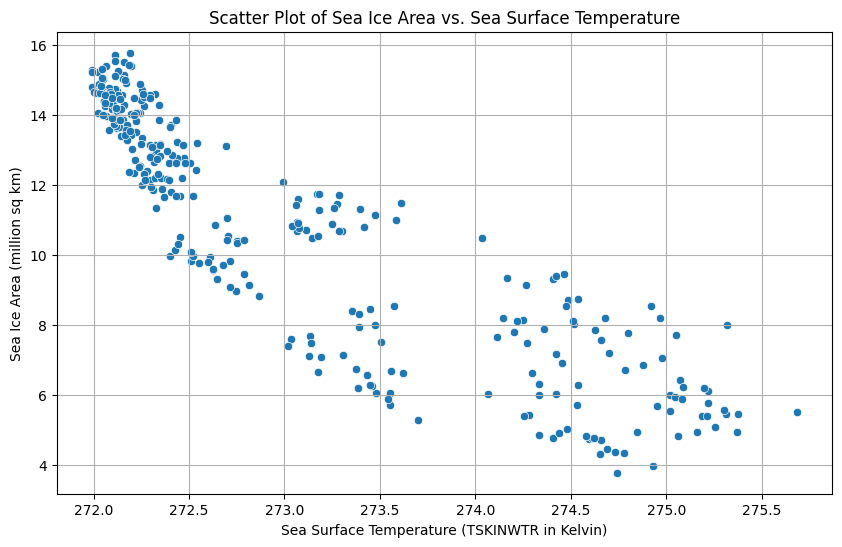

In [10]:
# To specifically check the correlation coefficient
correlation = merged_df['area_value'].corr(merged_df['TSKINWTR'])
print(f"Correlation between Sea Ice Area and Sea Surface Temperature (TSKINWTR): {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='TSKINWTR', y='area_value', data=merged_df)
plt.title('Scatter Plot of Sea Ice Area vs. Sea Surface Temperature')
plt.xlabel('Sea Surface Temperature (TSKINWTR in Kelvin)')
plt.ylabel('Sea Ice Area (million sq km)')
plt.grid(True)
plt.show()

### 해수면 온도 상승에 따른 해빙 면적

해수면 온도(TSKINWTR)와 해빙 면적 사이의 상관계수는 -0.89로 나타남. 이는 해수면 온도가 상승함에 따라 해빙 면적이 강하게 감소하는 경향이 있음을 의미한다.

그래프에서 해수면 온도(빨간색)가 올라갈 때 해빙 면적(파란색)이 줄어드는 것을 시각적으로도 확인할 수 있다.

###2. AO와 AREA

In [11]:
ao['Date'] = pd.to_datetime(ao['Date'])
ao['year_month'] = ao['Date'].dt.to_period('M')

# Merge the existing merged_df with the ao dataframe
merged_df_with_ao = pd.merge(merged_df, ao[['year_month', 'AO_Index']], on='year_month', how='inner')

display(merged_df_with_ao.head())

,time,FRSEAICE,TSKINWTR,T10M,HFLUXWTR,EFLUXWTR,U10M,V10M,year_month,year,month,area_value,month_num,Era,date,AO_Index
0,2000-01-01 00:30:00,0.502423,272.26678,250.90067,252.035550,89.892700,0.544332,0.148345,2000-01,2000,area_jan,14.25950,1,2000-2008 (pre),2000-01-01,0.665
1,2000-02-01 00:30:00,0.515255,272.16122,252.79323,221.314960,82.977910,-0.326276,-0.253599,2000-02,2000,area_feb,15.14771,2,2000-2008 (pre),2000-02-01,1.060
2,2000-03-01 00:30:00,0.517211,272.13068,254.50046,207.400000,80.391100,-0.634890,-0.397541,2000-03,2000,area_mar,15.25001,3,2000-2008 (pre),2000-03-01,-0.256
3,2000-04-01 00:30:00,0.518936,272.15040,260.33220,138.464160,63.603653,-0.286786,-0.351983,2000-04,2000,area_apr,14.57881,4,2000-2008 (pre),2000-04-01,-0.576
4,2000-05-01 00:30:00,0.500371,272.43660,267.82300,48.548542,32.018740,0.204275,-0.077439,2000-05,2000,area_may,13.21552,5,2000-2008 (pre),2000-05-01,1.152


Correlation between Arctic Oscillation Index (AO_Index) and Sea Ice Area: -0.02


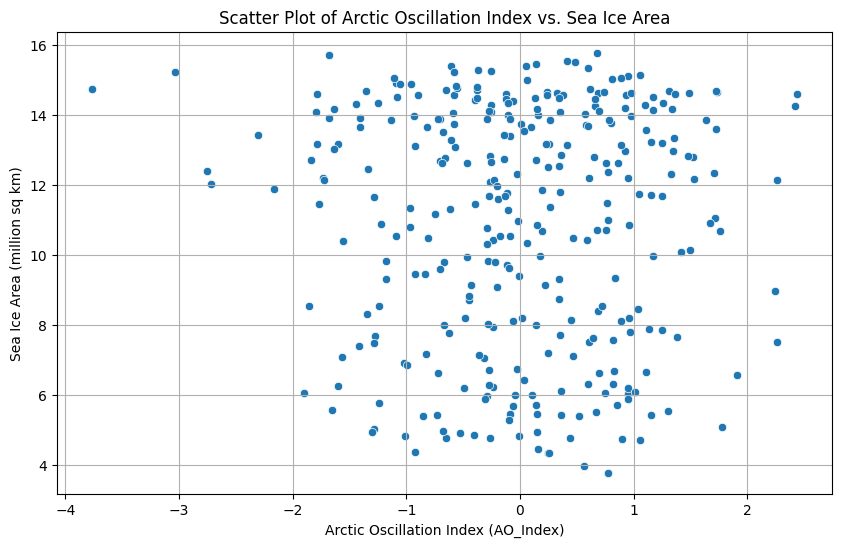

In [12]:
# Calculate the correlation between AO_Index and area_value
correlation_ao_area = merged_df_with_ao['AO_Index'].corr(merged_df_with_ao['area_value'])
print(f"Correlation between Arctic Oscillation Index (AO_Index) and Sea Ice Area: {correlation_ao_area:.2f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AO_Index', y='area_value', data=merged_df_with_ao)
plt.title('Scatter Plot of Arctic Oscillation Index vs. Sea Ice Area')
plt.xlabel('Arctic Oscillation Index (AO_Index)')
plt.ylabel('Sea Ice Area (million sq km)')
plt.grid(True)
plt.show()

###AO지수와 해빙면적의 상관관계

AO지수와 해빙 면적 사이의 상관계수는 -0.02이다. 이는 거의 상관관계가 없거나 매우 약한 음의 상관관계가 있음을 의미



In [13]:
europe['date'] = pd.to_datetime(europe['date'])
europe['year_month'] = europe['date'].dt.to_period('M')

# Merge europe and ao dataframes
merged_europe_ao = pd.merge(europe, ao[['year_month', 'AO_Index']], on='year_month', how='inner')

display(merged_europe_ao.head())

,year,mean_t850_celsius,date,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year_month,AO_Index
0,2000,-2.567078,2000-01-01,1.182831,5474.2715,0.000021,1015.94690,25.557714,2000-01,0.665
1,2000,-2.935486,2000-01-02,1.415955,5458.6577,0.000025,1015.32117,24.525616,2000-01,0.665
2,2000,-3.447266,2000-01-03,1.030762,5425.9585,0.000025,1012.57560,24.540684,2000-01,0.665
3,2000,-3.548401,2000-01-04,1.439240,5389.6665,0.000028,1008.87980,22.146442,2000-01,0.665
4,2000,-2.980896,2000-01-05,1.854767,5380.4897,0.000030,1006.60724,20.639778,2000-01,0.665


Correlations between Europe's Climate Variables and AO_Index:
  - mean_t850_celsius vs AO_Index: 0.11
  - mean_t2m_celsius vs AO_Index: 0.11
  - mean_prate vs AO_Index: 0.01
  - mean_slp_hpa vs AO_Index: -0.00
  - mean_wind_speed_250 vs AO_Index: 0.09


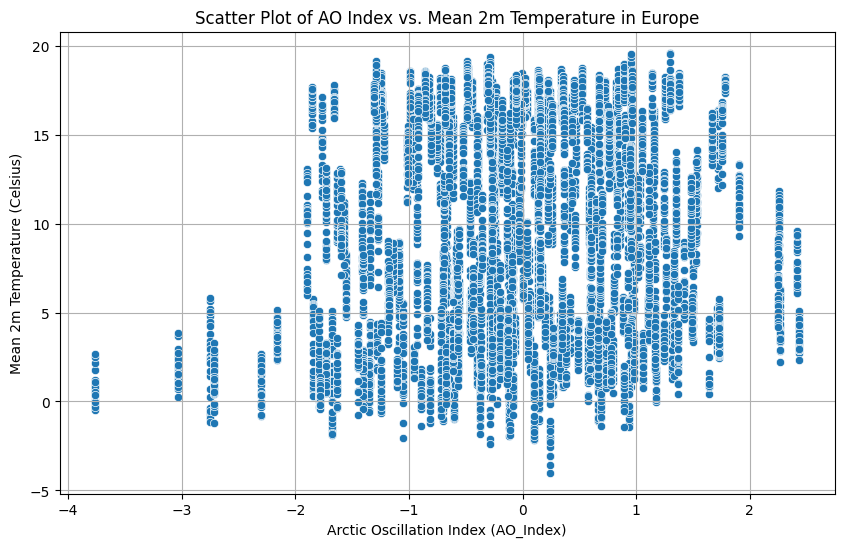

In [14]:
# Calculate correlations between Europe's climate variables and AO_Index
climate_variables = ['mean_t850_celsius', 'mean_t2m_celsius', 'mean_prate', 'mean_slp_hpa', 'mean_wind_speed_250']

print("Correlations between Europe's Climate Variables and AO_Index:")
for col in climate_variables:
    correlation = merged_europe_ao[col].corr(merged_europe_ao['AO_Index'])
    print(f"  - {col} vs AO_Index: {correlation:.2f}")

# Optional: Visualize a key correlation (e.g., mean_t2m_celsius vs AO_Index)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AO_Index', y='mean_t2m_celsius', data=merged_europe_ao)
plt.title('Scatter Plot of AO Index vs. Mean 2m Temperature in Europe')
plt.xlabel('Arctic Oscillation Index (AO_Index)')
plt.ylabel('Mean 2m Temperature (Celsius)')
plt.grid(True)
plt.show()

### AO지수는 다른 지표와 큰 상관 관계가 없다는 것을 알아냄.

### 3. 유럽 기후와 해수면 온도의 상관관계

In [15]:
# Ensure 'year_month' is in sst DataFrame (already done in previous steps)
# sst['year_month'] = sst['time'].dt.to_period('M')

# Ensure 'year_month' is in europe DataFrame (already done in previous steps)
# europe['year_month'] = europe['date'].dt.to_period('M')

# Merge sst and europe dataframes on year_month
merged_sst_europe = pd.merge(sst[['year_month', 'TSKINWTR']], europe, on='year_month', how='inner')

display(merged_sst_europe.head())

,year_month,TSKINWTR,year,mean_t850_celsius,date,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250
0,2000-01,272.26678,2000,-2.567078,2000-01-01,1.182831,5474.2715,0.000021,1015.94690,25.557714
1,2000-01,272.26678,2000,-2.935486,2000-01-02,1.415955,5458.6577,0.000025,1015.32117,24.525616
2,2000-01,272.26678,2000,-3.447266,2000-01-03,1.030762,5425.9585,0.000025,1012.57560,24.540684
3,2000-01,272.26678,2000,-3.548401,2000-01-04,1.439240,5389.6665,0.000028,1008.87980,22.146442
4,2000-01,272.26678,2000,-2.980896,2000-01-05,1.854767,5380.4897,0.000030,1006.60724,20.639778


Correlations between Europe's Climate Variables and Sea Surface Temperature (TSKINWTR):
  - mean_t850_celsius vs TSKINWTR: 0.84
  - mean_t2m_celsius vs TSKINWTR: 0.84
  - mean_prate vs TSKINWTR: -0.14
  - mean_slp_hpa vs TSKINWTR: -0.01
  - mean_wind_speed_250 vs TSKINWTR: -0.42


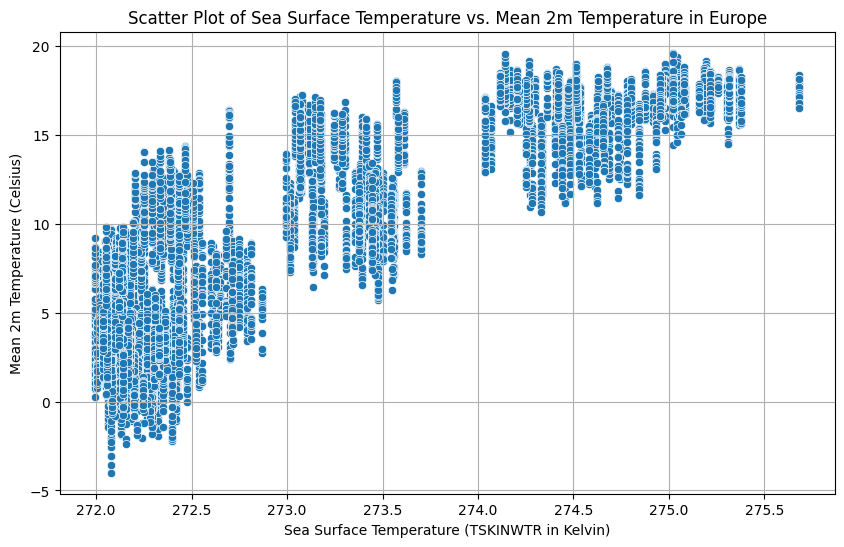

In [16]:
# Calculate correlations between Europe's climate variables and TSKINWTR
climate_variables = ['mean_t850_celsius', 'mean_t2m_celsius', 'mean_prate', 'mean_slp_hpa', 'mean_wind_speed_250']

print("Correlations between Europe's Climate Variables and Sea Surface Temperature (TSKINWTR):")
for col in climate_variables:
    correlation = merged_sst_europe[col].corr(merged_sst_europe['TSKINWTR'])
    print(f"  - {col} vs TSKINWTR: {correlation:.2f}")

# Optional: Visualize a key correlation (e.g., mean_t2m_celsius vs TSKINWTR)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TSKINWTR', y='mean_t2m_celsius', data=merged_sst_europe)
plt.title('Scatter Plot of Sea Surface Temperature vs. Mean 2m Temperature in Europe')
plt.xlabel('Sea Surface Temperature (TSKINWTR in Kelvin)')
plt.ylabel('Mean 2m Temperature (Celsius)')
plt.grid(True)
plt.show()

- mean_t850_celsius (850hPa 평균 온도) vs TSKINWTR: 0.84
- mean_t2m_celsius (지표면 2m 평균 온도) vs TSKINWTR: 0.84
- mean_prate (평균 강수량) vs TSKINWTR: -0.14
- mean_slp_hpa (평균 해수면 기압) vs TSKINWTR: -0.01
- mean_wind_speed_250 (250hPa 평균 풍속) vs TSKINWTR: -0.42

### 4. 유럽 이상기후 회귀 예측 모델 생성

2026년 유럽 이상기후를 예측하기 위해 모든 데이터를 활용하여 회귀 모델을 생성합니다. 주요 단계는 다음과 같습니다:
1.  **데이터 통합 및 월별 집계**: `sst`, `area`, `ao`, `europe` 데이터를 월별 기준으로 통합하고 집계합니다.
2.  **피처 엔지니어링**: 예측력을 높이기 위해 시계열 특성을 반영하는 지연(lagged) 및 이동 평균(rolling mean) 피처를 생성합니다.
3.  **데이터 준비**: 훈련 및 예측 데이터셋을 분리하고, 결측치를 처리합니다.
4.  **모델 훈련 및 예측**: LightGBM 회귀 모델을 사용하여 훈련하고 2026년 데이터를 예측합니다.
5.  **결과 시각화**: 예측 결과를 시각화하여 실제 데이터와 비교합니다.

### 1.1 기본 데이터 월별 집계 및 통합

`europe`, `sst`, `ao`, `area` 데이터를 월별로 집계하고 통합하여 `df_combined`를 생성합니다. 이는 모든 예측 모델링의 기초 데이터셋이 됩니다.

In [17]:
# Ensure 'date' column in europe is datetime and create 'year_month'
europe['date'] = pd.to_datetime(europe['date'])
europe['year_month'] = europe['date'].dt.to_period('M')

# Monthly aggregation for europe
europe_monthly_agg = europe.groupby('year_month').agg(
    mean_t850_celsius=('mean_t850_celsius', 'mean'),
    mean_t2m_celsius=('mean_t2m_celsius', 'mean'),
    mean_z500=('mean_z500', 'mean'),
    mean_prate=('mean_prate', 'mean'),
    mean_slp_hpa=('mean_slp_hpa', 'mean'),
    mean_wind_speed_250=('mean_wind_speed_250', 'mean')
).reset_index()
europe_monthly_agg['year'] = europe_monthly_agg['year_month'].dt.year
europe_monthly_agg['month'] = europe_monthly_agg['year_month'].dt.month
# The .set_index() call was removed here to prevent 'year_month' from becoming an ambiguous label/index.

display(europe_monthly_agg.head())

,year_month,mean_t850_celsius,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year,month
0,2000-01,-4.181620,1.023189,5424.016813,0.000023,1014.291652,26.049841,2000,1
1,2000-02,-3.147531,2.413326,5417.767407,0.000025,1011.907288,24.780429,2000,2
2,2000-03,-2.451394,3.575524,5450.330084,0.000022,1014.241815,24.250502,2000,3
3,2000-04,0.867558,7.105605,5496.645230,0.000025,1011.548113,21.808205,2000,4
4,2000-05,4.629686,10.712463,5593.623074,0.000020,1014.013966,20.220714,2000,5


In [18]:
# Ensure 'Date' column in ao is datetime and create 'year_month'
ao['Date'] = pd.to_datetime(ao['Date'])
ao['year_month'] = ao['Date'].dt.to_period('M')

# Monthly aggregation for ao
ao_monthly = ao.groupby('year_month')['AO_Index'].mean().reset_index()
# The .set_index() call was removed here to prevent 'year_month' from becoming an ambiguous label/index.

display(ao_monthly.head())

,year_month,AO_Index
0,2000-01,0.665
1,2000-02,1.060
2,2000-03,-0.256
3,2000-04,-0.576
4,2000-05,1.152


In [19]:
# Ensure 'time' column in sst is datetime and create 'year_month'
sst['time'] = pd.to_datetime(sst['time'])
sst['year_month'] = sst['time'].dt.to_period('M')

# Monthly aggregation for sst (using TSKINWTR)
sst_monthly = sst.groupby('year_month')['TSKINWTR'].mean().reset_index()
# The .set_index() call was removed here to prevent 'year_month' from becoming an ambiguous label/index.

display(sst_monthly.head())

,year_month,TSKINWTR
0,2000-01,272.26678
1,2000-02,272.16122
2,2000-03,272.13068
3,2000-04,272.15040
4,2000-05,272.43660


In [20]:
# Ensure 'date' column in area is datetime and create 'year_month'
area['date'] = pd.to_datetime(area['year'].astype(str) + '-' + area['month_num'].astype(str) + '-01')
area['year_month'] = area['date'].dt.to_period('M')

# Monthly aggregation for area
area_monthly = area.groupby('year_month')['area_value'].mean().reset_index()
# The .set_index() call was removed here to prevent 'year_month' from becoming an ambiguous label/index.

display(area_monthly.head())

,year_month,area_value
0,2000-01,14.25950
1,2000-02,15.14771
2,2000-03,15.25001
3,2000-04,14.57881
4,2000-05,13.21552


이 부분은 europe, sst, ao, area 데이터를 월별로 집계하고 통합하여 df_combined라는 기본 데이터셋을 생성

europe_monthly_agg: europe 데이터프레임(일별 유럽 기후 데이터)을 월별로 집계. mean_t850_celsius, mean_t2m_celsius, mean_z500, mean_prate, mean_slp_hpa, mean_wind_speed_250와 같은 다양한 기온, 기압, 강수량, 풍속 평균을 계산. 또한 year_month 컬럼에서 year와 month를 추출. 이전에 set_index() 호출이 있었으나, 이후 병합 작업을 위해 year_month가 인덱스가 아닌 일반 컬럼으로 유지되도록 수정.

ao_monthly: ao 데이터프레임에서 'AO_Index'(북극 진동 지수)를 월별 평균으로 집계. 이 역시 year_month가 일반 컬럼으로 유지.

sst_monthly: sst 데이터프레임에서 'TSKINWTR'(해수면 온도)을 월별 평균으로 집계. 이 역시 year_month가 일반 컬럼으로 유지.

area_monthly: area 데이터프레임에서 'area_value'(해빙 면적)를 월별 평균으로 집계. 이 역시 year_month가 일반 컬럼으로 유지.

### 1.2 모든 월별 집계 데이터 통합

이제 개별적으로 준비된 월별 데이터를 `df_combined`로 통합합니다. 이를 통해 모든 변수를 함께 분석하고 피처 엔지니어링을 수행할 수 있는 단일 데이터셋을 만듭니다.

In [21]:
# Merge all monthly aggregated dataframes into a single dataframe (df_combined)
# Use 'inner' join to ensure only common year_month periods are included
df_combined = europe_monthly_agg.merge(sst_monthly, on='year_month', how='inner', suffixes=('_europe', '_sst'))
df_combined = df_combined.merge(ao_monthly, on='year_month', how='inner', suffixes=('', '_ao'))
df_combined = df_combined.merge(area_monthly, on='year_month', how='inner', suffixes=('', '_area'))

# Set the date index for df_combined
df_combined = df_combined.set_index(pd.to_datetime(df_combined['year_month'].astype(str) + '-01'))

# Drop the 'year_month' column as it's now part of the index
df_combined = df_combined.drop(columns=['year_month'])

display(df_combined.head())

,mean_t850_celsius,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year,month,TSKINWTR,AO_Index,area_value
year_month,,,,,,,,,,,
2000-01-01,-4.181620,1.023189,5424.016813,0.000023,1014.291652,26.049841,2000,1,272.26678,0.665,14.25950
2000-02-01,-3.147531,2.413326,5417.767407,0.000025,1011.907288,24.780429,2000,2,272.16122,1.060,15.14771
2000-03-01,-2.451394,3.575524,5450.330084,0.000022,1014.241815,24.250502,2000,3,272.13068,-0.256,15.25001
2000-04-01,0.867558,7.105605,5496.645230,0.000025,1011.548113,21.808205,2000,4,272.15040,-0.576,14.57881
2000-05-01,4.629686,10.712463,5593.623074,0.000020,1014.013966,20.220714,2000,5,272.43660,1.152,13.21552


### 1.2 모든 월별 집계 데이터 통합
- 데이터 프레임 병합

(europe_monthly_agg, sst_monthly, ao_monthly, area_monthly)을 year_month 컬럼을 기준으로 inner 조인하여 df_combined라는 단일 데이터프레임으로 통합

최종적으로 df_combined의 인덱스를 year_month를 기반으로 한 날짜 인덱스로 설정하고, 중복을 피하기 위해 year_month 컬럼은 삭제



In [22]:
# 1. 데이터 준비 및 확장 (2026년 12월까지)

# Helper function
def get_monthly_average(df, feature_col, month_num):
    if 'month' not in df.columns and isinstance(df.index, pd.DatetimeIndex):
        df_copy = df.copy()
        df_copy['month'] = df_copy.index.month
    elif 'month' not in df.columns and 'year_month' in df.columns:
        df_copy = df.copy()
        df_copy['month'] = df_copy['year_month'].dt.month
    else:
        df_copy = df.copy()

    avg_value = df_copy[df_copy['month'] == month_num][feature_col].mean()
    return avg_value

europ_monthly_agg_copy = europe_monthly_agg.copy()
europ_monthly_agg_copy['month'] = europ_monthly_agg_copy['year_month'].dt.month.astype(int)

ao_monthly_copy = ao_monthly.copy()
ao_monthly_copy['month'] = ao_monthly_copy['year_month'].dt.month.astype(int)

sst_monthly_copy = sst_monthly.copy()
sst_monthly_copy['month'] = sst_monthly_copy['year_month'].dt.month.astype(int)

area_monthly_copy = area_monthly.copy()
area_monthly_copy['month'] = area_monthly_copy['year_month'].dt.month.astype(int)

# Extend to December 2026
months_to_extend = [6, 7, 8, 9, 10, 11, 12]

new_entries_list = []
for month_num in months_to_extend:
    current_date = pd.Timestamp(year=2026, month=month_num, day=1)
    new_entry = {'date': current_date, 'year_month': current_date.to_period('M')}

    new_entry['AO_Index'] = get_monthly_average(ao_monthly_copy, 'AO_Index', month_num)
    new_entry['TSKINWTR'] = get_monthly_average(sst_monthly_copy, 'TSKINWTR', month_num)
    new_entry['area_value'] = get_monthly_average(area_monthly_copy, 'area_value', month_num)

    for col in ['mean_t850_celsius', 'mean_z500', 'mean_prate', 'mean_slp_hpa', 'mean_wind_speed_250']:
        new_entry[col] = get_monthly_average(europ_monthly_agg_copy, col, month_num)
    new_entry['mean_t2m_celsius'] = np.nan

    new_entries_list.append(new_entry)

new_df_entries = pd.DataFrame(new_entries_list).set_index('date')
new_df_entries['year'] = new_df_entries.index.year
new_df_entries['month'] = new_df_entries.index.month

existing_cols = df_combined.columns.tolist()
new_df_entries_aligned = pd.DataFrame(index=new_df_entries.index, columns=existing_cols)
for col in new_df_entries.columns:
    if col in existing_cols:
        new_df_entries_aligned[col] = new_df_entries[col]

df_extended = pd.concat([df_combined, new_df_entries_aligned[new_df_entries_aligned.index > df_combined.index.max()]])

# 2. 피처 엔지니어링
df_extended['year'] = df_extended.index.year
df_extended['month'] = df_extended.index.month

lag_features_target = ['mean_t2m_celsius', 'TSKINWTR', 'area_value', 'AO_Index']
lags = [2]

for col in lag_features_target:
    for lag in lags:
        df_extended.loc[:, f'{col}_lag{lag}'] = df_extended[col].shift(lag)

df_extended.loc[:, 'AO_Index_lag2_rolling_mean_3'] = df_extended['AO_Index_lag2'].rolling(window=3).mean()
df_extended = df_extended.drop(columns=['year_month'], errors='ignore')

feature_cols_for_fillna = [col for col in df_extended.columns if col != 'mean_t2m_celsius']
for col in feature_cols_for_fillna:
    df_extended.loc[:, col] = df_extended.loc[:, col].ffill().bfill()

df_extended = df_extended.dropna(subset=feature_cols_for_fillna)
display(df_extended.tail())

,mean_t850_celsius,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year,month,TSKINWTR,AO_Index,area_value,mean_t2m_celsius_lag2,TSKINWTR_lag2,area_value_lag2,AO_Index_lag2,AO_Index_lag2_rolling_mean_3
2026-08-01,10.811432,NaN,5716.562837,0.000020,1013.129747,19.980786,2026,8,275.081373,-0.141577,5.935163,11.899121,273.241700,11.044643,0.105654,0.364551
2026-09-01,7.762546,NaN,5668.393702,0.000022,1013.902236,22.079274,2026,9,274.522540,0.128192,5.112551,11.899121,274.467355,8.303331,0.076923,0.376859
2026-10-01,4.178776,NaN,5589.129119,0.000026,1013.204219,23.458391,2026,10,273.376981,0.098269,6.964852,11.899121,275.081373,5.935163,-0.141577,0.013667
2026-11-01,0.870786,NaN,5516.713139,0.000027,1012.862819,24.759613,2026,11,272.637940,-0.075577,9.876553,11.899121,274.522540,5.112551,0.128192,0.021179
2026-12-01,-1.552806,NaN,5468.649551,0.000027,1013.376571,25.346278,2026,12,272.349340,-0.203115,12.182818,11.899121,273.376981,6.964852,0.098269,0.028295


In [23]:
display(df_extended.head())

,mean_t850_celsius,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year,month,TSKINWTR,AO_Index,area_value,mean_t2m_celsius_lag2,TSKINWTR_lag2,area_value_lag2,AO_Index_lag2,AO_Index_lag2_rolling_mean_3
2000-01-01,-4.181620,1.023189,5424.016813,0.000023,1014.291652,26.049841,2000,1,272.26678,0.665,14.25950,1.023189,272.26678,14.25950,0.665,0.489667
2000-02-01,-3.147531,2.413326,5417.767407,0.000025,1011.907288,24.780429,2000,2,272.16122,1.060,15.14771,1.023189,272.26678,14.25950,0.665,0.489667
2000-03-01,-2.451394,3.575524,5450.330084,0.000022,1014.241815,24.250502,2000,3,272.13068,-0.256,15.25001,1.023189,272.26678,14.25950,0.665,0.489667
2000-04-01,0.867558,7.105605,5496.645230,0.000025,1011.548113,21.808205,2000,4,272.15040,-0.576,14.57881,2.413326,272.16122,15.14771,1.060,0.489667
2000-05-01,4.629686,10.712463,5593.623074,0.000020,1014.013966,20.220714,2000,5,272.43660,1.152,13.21552,3.575524,272.13068,15.25001,-0.256,0.489667


In [24]:
df_extended.head()

,mean_t850_celsius,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year,month,TSKINWTR,AO_Index,area_value,mean_t2m_celsius_lag2,TSKINWTR_lag2,area_value_lag2,AO_Index_lag2,AO_Index_lag2_rolling_mean_3
2000-01-01,-4.181620,1.023189,5424.016813,0.000023,1014.291652,26.049841,2000,1,272.26678,0.665,14.25950,1.023189,272.26678,14.25950,0.665,0.489667
2000-02-01,-3.147531,2.413326,5417.767407,0.000025,1011.907288,24.780429,2000,2,272.16122,1.060,15.14771,1.023189,272.26678,14.25950,0.665,0.489667
2000-03-01,-2.451394,3.575524,5450.330084,0.000022,1014.241815,24.250502,2000,3,272.13068,-0.256,15.25001,1.023189,272.26678,14.25950,0.665,0.489667
2000-04-01,0.867558,7.105605,5496.645230,0.000025,1011.548113,21.808205,2000,4,272.15040,-0.576,14.57881,2.413326,272.16122,15.14771,1.060,0.489667
2000-05-01,4.629686,10.712463,5593.623074,0.000020,1014.013966,20.220714,2000,5,272.43660,1.152,13.21552,3.575524,272.13068,15.25001,-0.256,0.489667


get_monthly_average 함수: 이 헬퍼 함수는 주어진 데이터프레임과 월에 대해 특정 피처의 월별 역사적 평균을 계산합니다. 이 평균은 실제 데이터가 없는 미래 월의 값을 추정하는 데 사용됩니다.

데이터 확장: ao_monthly, sst_monthly, area_monthly, europe_monthly_agg 데이터프레임을 2026년 8월까지 확장합니다. 2026년 6월, 7월, 8월과 같은 미래 월에 대해서는 AO_Index, TSKINWTR, area_value, 유럽 기후 피처의 값을 해당 월의 과거 월별 평균으로 채웁니다. 예측 대상인 mean_t2m_celsius는 예측해야 할 값이므로 np.nan으로 명시적으로 설정됩니다.

df_extended 생성: 원본 df_combined와 새롭게 생성된 미래 엔트리를 연결하여 df_extended 데이터프레임을 만듭니다.

피처 엔지니어링 (시간 기반 피처): 데이터프레임의 인덱스(날짜)에서 year와 month를 추출하여 추가 피처로 사용합니다.

피처 엔지니어링 (시차(Lag) 피처): mean_t2m_celsius, TSKINWTR, area_value, AO_Index에 대해 2개월 시차(_lag2) 피처를 생성합니다. 이는 모델이 시계열 종속성을 학습할 수 있도록 과거의 값을 새로운 피처로 추가하는 것입니다.

피처 엔지니어링 (이동 평균(Rolling Mean) 피처): AO_Index_lag2 피처에 대해 3개월 이동 평균(_rolling_mean_3)을 계산합니다. 이동 평균은 단기적인 변동을 완화하고 장기적인 추세를 강조하는 데 도움이 됩니다.

결측치(NaN) 처리: 남아있는 결측치(NaN)를 bfill(후방 채우기)과 ffill(전방 채우기)을 조합하여 채웁니다. 이는 모든 피처가 모델을 위한 유효한 값을 갖도록 하면서, 미래 예측 월의 타겟 변수(mean_t2m_celsius)에 있는 NaN 값은 그대로 유지하기 위함입니다. 이 과정 후에도 NaN이 남아있는 초기 행(예: 시차 피처 생성으로 인한)은 삭제

#### 2. Train / Test / Predict 데이터셋 분리 (시계열 검증 구조)

데이터 누출 방지를 위해 시간 순서 기준으로 데이터를 Train, Validation, Predict 세트로 분리합니다.

In [29]:
target = 'mean_t2m_celsius'
features = [col for col in df_extended.columns if col != target]

X = df_extended[features]
y = df_extended[target]

# 데이터 분할 (시간 순서 기준)
X_train = X[X.index.year <= 2024]
y_train = y[y.index.year <= 2024]

# Validation Set: 2025년 전체 + 2026년 1월부터 5월까지
X_val = X[(X.index.year == 2025) | ((X.index.year == 2026) & (X.index.month <= 5))]
y_val = y[(y.index.year == 2025) | ((y.index.year == 2026) & (y.index.month <= 5))]

# Predict Set: 2026년 7월 1일 ~ 2026년 12월 31일
X_predict = X[(X.index.year == 2026) & (X.index.month >= 7) & (X.index.month <= 12)]

print(f"Train set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Predict set shape: {X_predict.shape}")

Train set shape: (300, 15), (300,)
Validation set shape: (17, 15), (17,)
Predict set shape: (6, 15)


mean_t2m_celsius를 타겟 변수로, 그 외 모든 컬럼을 피처로 정의

X,y를 시간 기반으로 분할한다.

2024년까지의 데이터를 포함하여 Train data로 사용

X_predict(피처 데이터): 2026년 7월가 8월의 피처 데이터를 포함하며 이 기간의  mean_t2m_celsius를 예측하게 된다.


In [30]:
display(X_predict.head())

,mean_t850_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,year,month,TSKINWTR,AO_Index,area_value,mean_t2m_celsius_lag2,TSKINWTR_lag2,area_value_lag2,AO_Index_lag2,AO_Index_lag2_rolling_mean_3
2026-07-01,11.129692,5721.410756,0.000022,1013.105397,19.720630,2026,7,274.467355,0.076923,8.303331,11.899121,272.463560,12.188600,0.948000,0.638333
2026-08-01,10.811432,5716.562837,0.000020,1013.129747,19.980786,2026,8,275.081373,-0.141577,5.935163,11.899121,273.241700,11.044643,0.105654,0.364551
2026-09-01,7.762546,5668.393702,0.000022,1013.902236,22.079274,2026,9,274.522540,0.128192,5.112551,11.899121,274.467355,8.303331,0.076923,0.376859
2026-10-01,4.178776,5589.129119,0.000026,1013.204219,23.458391,2026,10,273.376981,0.098269,6.964852,11.899121,275.081373,5.935163,-0.141577,0.013667
2026-11-01,0.870786,5516.713139,0.000027,1012.862819,24.759613,2026,11,272.637940,-0.075577,9.876553,11.899121,274.522540,5.112551,0.128192,0.021179


#### 3. 모델 학습 및 예측

LightGBM Regressor 모델을 사용하여 훈련하고, Validation Set으로 성능(RMSE)을 평가한 후, Predict Set으로 2026년 7월 및 8월의 유럽 기온을 예측합니다.

### Validation을 2025-01-01 부터 2026-05-01까지 했을 때

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1350
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 15
[LightGBM] [Info] Start training from score 8.967606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Predicted_Mean_T2m_Celsius
Date,
2026-07-01,17.454821
2026-08-01,17.300775
2026-09-01,14.229912
2026-10-01,9.936028
2026-11-01,5.903472
2026-12-01,3.062035


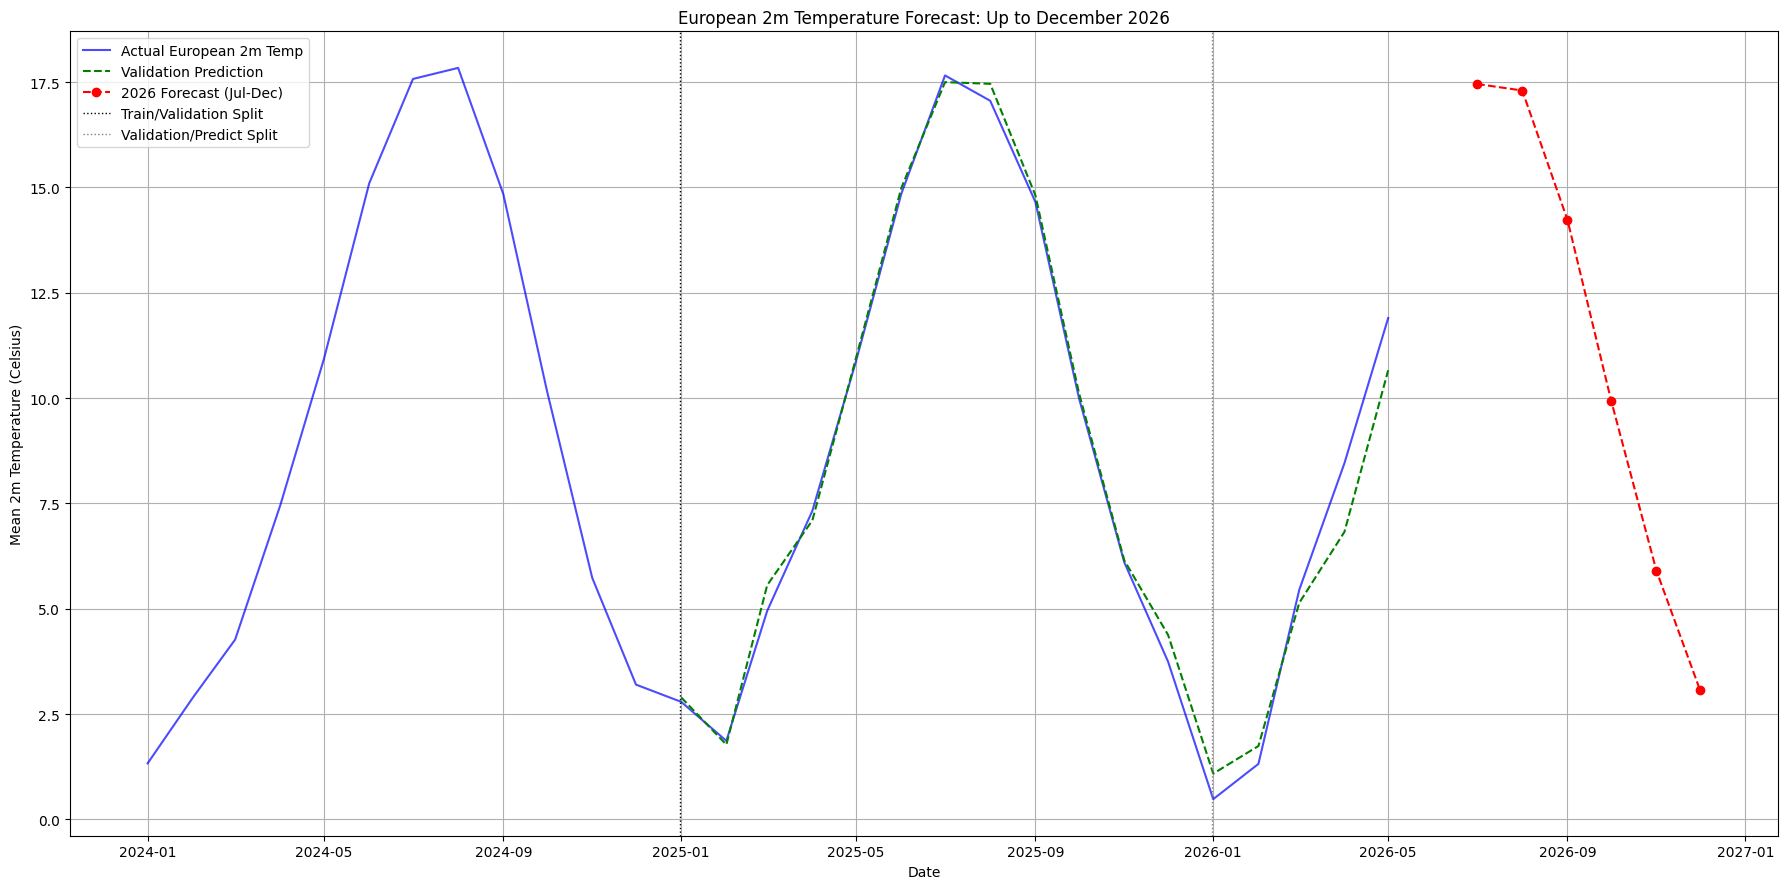

In [31]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# 모델 훈련
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# Validation Set 성능 평가
y_val_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Validation RMSE: {rmse:.4f}")

# Predict Set으로 최종 예측 (7월~12월)
X_predict_aligned = X_predict[X_train.columns]

if not X_predict_aligned.empty:
    final_predictions_2026 = model.predict(X_predict_aligned)
    predictions_df = pd.DataFrame({
        'Date': X_predict.index,
        'Predicted_Mean_T2m_Celsius': final_predictions_2026
    }).set_index('Date')

    print("\n2026년 7월~12월 유럽 기온 예측값:")
    display(predictions_df)

    # 시각화
    plt.figure(figsize=(18, 9))
    plt.plot(y.index[y.index.year >= 2024], y[y.index.year >= 2024], label='Actual European 2m Temp', color='blue', alpha=0.7)
    plt.plot(y_val.index, y_val_pred, label='Validation Prediction', color='green', linestyle='--')
    plt.plot(predictions_df.index, predictions_df['Predicted_Mean_T2m_Celsius'], label='2026 Forecast (Jul-Dec)', color='red', marker='o', linestyle='--')

    plt.axvline(pd.Timestamp('2024-12-31'), color='black', linestyle=':', lw=1, label='Train/Validation Split')
    plt.axvline(pd.Timestamp('2025-12-31'), color='gray', linestyle=':', lw=1, label='Validation/Predict Split')

    plt.title('European 2m Temperature Forecast: Up to December 2026')
    plt.xlabel('Date')
    plt.ylabel('Mean 2m Temperature (Celsius)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Prediction set is empty.")

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val, y_val_pred)
print(f"Validation MAE: {mae:.4f}")

# Calculate R-squared (R²)
r2 = r2_score(y_val, y_val_pred)
print(f"Validation R-squared: {r2:.4f}")

Validation MAE: 0.4108
Validation R-squared: 0.9881


In [28]:
display(predictions_df.head())

,Predicted_Mean_T2m_Celsius
Date,
2026-07-01,17.454821
2026-08-01,17.300775
2026-09-01,14.229912
2026-10-01,9.936028
2026-11-01,5.903472


### Validation을 2025년만 했을때.

In [35]:
target = 'mean_t2m_celsius'
features = [col for col in df_extended.columns if col != target]

X = df_extended[features]
y = df_extended[target]

# 데이터 분할 (시간 순서 기준)
X_train = X[X.index.year <= 2024]
y_train = y[y.index.year <= 2024]

# Validation Set: 2025년 전체 + 2026년 1월부터 5월까지
X_val_2 = X[(X.index.year == 2025)]
y_val_2 = y[(y.index.year == 2025)]

# Predict Set: 2026년 7월 1일 ~ 2026년 12월 31일
X_predict = X[(X.index.year == 2026) & (X.index.month >= 7) & (X.index.month <= 12)]

print(f"Train set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val_2.shape}, {y_val_2.shape}")
print(f"Predict set shape: {X_predict.shape}")

Train set shape: (300, 15), (300,)
Validation set shape: (12, 15), (12,)
Predict set shape: (6, 15)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1350
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 15
[LightGBM] [Info] Start training from score 8.967606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Predicted_Mean_T2m_Celsius
Date,
2026-07-01,17.454821
2026-08-01,17.300775
2026-09-01,14.229912
2026-10-01,9.936028
2026-11-01,5.903472
2026-12-01,3.062035


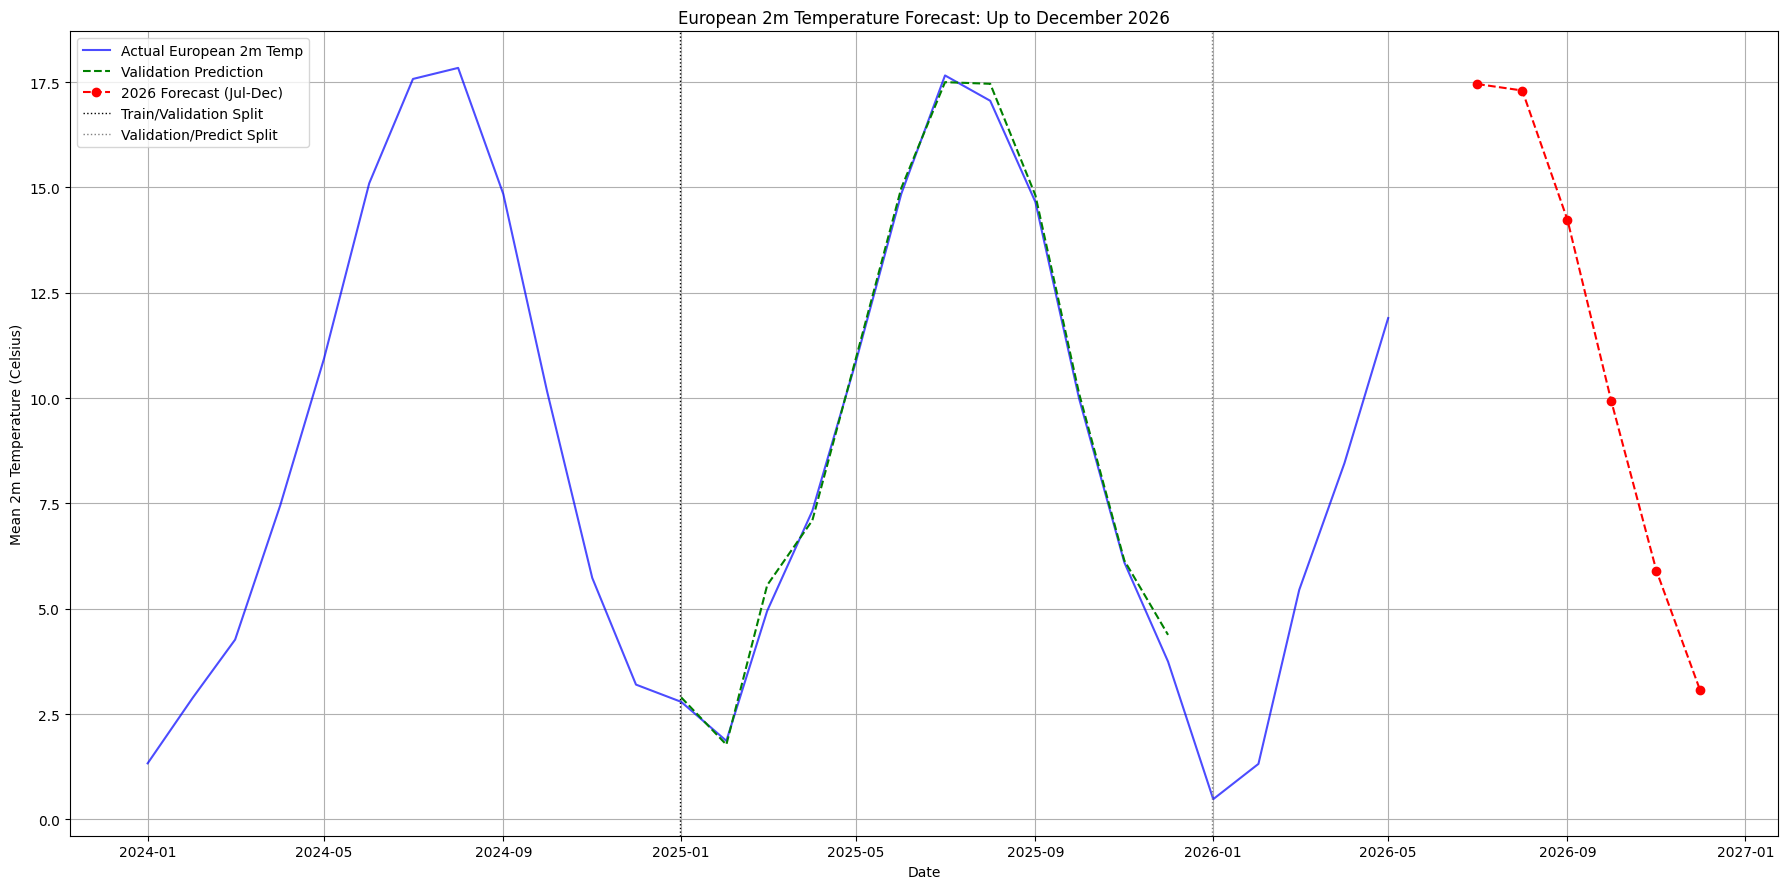

In [36]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# 모델 훈련
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# Validation Set 성능 평가
y_val_pred = model.predict(X_val_2)
rmse = np.sqrt(mean_squared_error(y_val_2, y_val_pred))
print(f"Validation RMSE: {rmse:.4f}")

# Predict Set으로 최종 예측 (7월~12월)
X_predict_aligned = X_predict[X_train.columns]

if not X_predict_aligned.empty:
    final_predictions_2026 = model.predict(X_predict_aligned)
    predictions_df = pd.DataFrame({
        'Date': X_predict.index,
        'Predicted_Mean_T2m_Celsius': final_predictions_2026
    }).set_index('Date')

    print("\n2026년 7월~12월 유럽 기온 예측값:")
    display(predictions_df)

    # 시각화
    plt.figure(figsize=(18, 9))
    plt.plot(y.index[y.index.year >= 2024], y[y.index.year >= 2024], label='Actual European 2m Temp', color='blue', alpha=0.7)
    plt.plot(y_val_2.index, y_val_pred, label='Validation Prediction', color='green', linestyle='--')
    plt.plot(predictions_df.index, predictions_df['Predicted_Mean_T2m_Celsius'], label='2026 Forecast (Jul-Dec)', color='red', marker='o', linestyle='--')

    plt.axvline(pd.Timestamp('2024-12-31'), color='black', linestyle=':', lw=1, label='Train/Validation Split')
    plt.axvline(pd.Timestamp('2025-12-31'), color='gray', linestyle=':', lw=1, label='Validation/Predict Split')

    plt.title('European 2m Temperature Forecast: Up to December 2026')
    plt.xlabel('Date')
    plt.ylabel('Mean 2m Temperature (Celsius)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Prediction set is empty.")

In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val_2, y_val_pred)
print(f"Validation MAE: {mae:.4f}")

# Calculate R-squared (R²)
r2 = r2_score(y_val_2, y_val_pred)
print(f"Validation R-squared: {r2:.4f}")

Validation MAE: 0.2310
Validation R-squared: 0.9969
